In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

# Условие

**В этом домашнем задании вы должны написать свою сплит систему для проведения A/B тестов**

В предоставленных данных есть 50000 юзеров, для каждого есть запись какой-то метрики за 2 года (730 дней).

Данные: https://disk.yandex.ru/d/2mH8fuKCKLeozg


### Ваша задача:

1) Написать алгоритм, которые разбивает данные на 3 группы размера около 5000, которые будут считаться "похожими".

- Для этого вам самостоятельно нужно решить, какие критерии схожести тут применимы и построить необходимые тесты для выбора этих групп.

- Данные 3 группы должны считаться похожими на основе ваших метрик.

- Разбиение затем будет протестировано на следующих 2х годах нами.

2) Визуализировать распределения выбранных вами метрик для найденных групп и сравнить с аналогичными разультатами для случайных групп

### Нужно реализовать следующие функции (вы можете добавлять какие-то побочные, если считаете нужным):

`generate_groups`  - функция, которая по данным и числу групп делает случайное разбиение данных на примерно одинаковые части по количеству групп

`conduct_test_on_pair` - функция проводит статистические тесты между двумя данными группами и возвращает нужные статистики и результаты

`conduct_tests` -- по списку групп и количеству необходимых похожих групп (зафиксировано в условии задачи как 3) перебирает возможные тройки групп пока не найдет похожие, критерий остановки за вами

`find_groups` -- берет данные и число групп, на которое вы их разбиваете и ищет 3 группы удовлетворяющие вашим критериям схожести.

Рекомендуем начинать с того, чтобы искать разбиение на 2 группы, а не 3, чтобы проверить, что сплит система работает адекватно. Задача с двумя группами зачастую сильно проще, чем с тремя.

Группы должны состоять из уникальных клиентов без дубликатов, один клиент может быть только в одной группе. То есть должны выбирать группы из датасета без повторений и у групп не должно быть пересечений.

 Про то, по каким параметрам оценивать группы: в этом задании вам требуется найти группы, в которых распределения **средних значений и дисперсии данной последовательности** по пользователям похожи. То есть вам нужно вычислить среднее значение и дисперсию данной последовательности для каждого пользователя, а затем проверить, что распределения результатов между группами схожи по вашим тестам.


**Замечание**: Для разбиения на группы и сравнения похожести можете брать любую метрику и считать любой критерии, но мы будем сравнивать именно метрику «среднее» и дисперсию на следующих по времени данных

#### Про систему оценивания: При оценивании мы будем проверять полученные вами группы как на этих данных, так и на следующих двух годах. При проверке будем учитывать и качество полученных групп при помощи метрик.

## Напишите следующие функции

In [1]:
def generate_groups(df, group_num):
    """
    Splits users into group_num groups of similar size

    df : Dataframe with all user data, can be pandas, numpy or whatever you like
    group_num : number of groups to split into

    returns a list of dataframes of generated groups
    """
    pass

def conduct_tests_on_pair(df_1, df_2):
    """
    Conducts statistical test or tests on two given groups to decide if they are similar

    df_i : Dataframe of users of a single group

    returns p-value or anything you need further
    """
    pass

def conduct_tests(dfs, group_num):
    """
    Goal is to find out if there is group_num groups in the dfs list which are similar enough according to your criterion.
    For every (or maybe not every) selection of group_num groups from the dfs list and conducts pairwise tests on selected subset using conduct_tests_on_pair.

    dfs : list of dataframes of groups

    returns list of selected groups or None if there are no similar groups
    """
    pass

def find_groups(df, group_num):
    """
    Splits df imto groups and conducts tests on subsets of the groups until necessary groups are found
    """
    for i in range(100000):
        dfs = generate_groups(df, group_num)
        result = conduct_tests(dfs, 3)

        if result is not None:
            return result

In [28]:
df = pd.read_csv('train_data.csv')

In [29]:
df.head()

,2019-01-01,2019-01-02,2019-01-03,2019-01-04,2019-01-05,2019-01-06,2019-01-07,2019-01-08,2019-01-09,2019-01-10,...,2020-12-21,2020-12-22,2020-12-23,2020-12-24,2020-12-25,2020-12-26,2020-12-27,2020-12-28,2020-12-29,2020-12-30
0,-3.533155,-4.475755,-4.748074,-5.569953,-8.017896,-12.396771,-11.853961,-12.046498,-10.297042,-10.075553,...,-168.163849,-168.728405,-168.971555,-168.824042,-167.700081,-167.634364,-167.856116,-168.743465,-168.231590,-167.913551
1,-3.824475,-1.530769,0.038338,-1.475237,-1.602029,-0.992509,0.302906,1.789140,4.177589,9.273372,...,75.919063,72.909418,75.289867,77.770907,74.099941,72.411474,67.472791,67.084800,66.805609,72.078232
2,-1.616434,-4.658834,-6.746498,-9.979424,-11.683396,-9.507703,-7.614438,-9.735666,-10.754863,-11.058539,...,47.759469,46.596598,50.135737,48.424880,47.740658,46.676116,45.611939,43.331310,45.655325,39.770838
3,-0.157282,1.827617,-2.585284,-4.397189,0.113494,7.614615,5.456654,5.928451,6.953534,4.514409,...,318.364962,319.281629,322.614999,325.200268,324.745069,326.519830,326.467326,321.806523,321.286907,323.570847
4,2.056969,10.187929,8.559520,8.579555,9.464262,9.038088,10.875990,9.883777,8.026472,13.040411,...,-38.079584,-38.515039,-38.031876,-36.610698,-37.753387,-35.470938,-35.454435,-35.026979,-35.633306,-35.460477


In [8]:
df.shape[1]

730

In [ ]:
def generate_groups_greedy(df, group_num, group_size=5000):
    # жадно находим группы
    
    data = df.values
    user_ids = df.index.values
    
    n_users, n_days = data.shape
    
    candidates = list(range(n_users))
    np.random.shuffle(candidates)
    
    groups = []
    for _ in range(group_num):
        groups.append({
            "indices": [],
            "count": 0,
            "sum": np.zeros(n_days),
            "sumsq": np.zeros(n_days)
        })
    
    for pos in range(group_size):
        print(f"Заполнение позиции {pos+1} из {group_size}")
        for g in range(group_num):
            # формирование эталона из других групп, у которых уже есть данные
            other_means = []
            other_vars = []
            for k in range(group_num):
                if k != g and groups[k]["count"] > 0:
                    count_k = groups[k]["count"]
                    mean_k = groups[k]["sum"] / count_k
                    var_k = groups[k]["sumsq"] / count_k - mean_k**2
                    other_means.append(mean_k)
                    other_vars.append(var_k)
            if len(other_means) > 0:
                benchmark_mean = np.mean(other_means, axis=0)
                benchmark_var = np.mean(other_vars, axis=0)
                use_benchmark = True
            else:
                use_benchmark = False
            
            # если группа пуста и эталон недоступен, выбираем "типичного" кандидата
            if groups[g]["count"] == 0 and not use_benchmark:
                if len(candidates) == 0:
                    raise ValueError("Нет доступных кандидатов для выбора")
                # pассчитываем среднее значение по дням для всех оставшихся кандидатов
                candidate_data = data[candidates, :]
                candidate_means = candidate_data.mean(axis=1)
                lower = np.percentile(candidate_means, 20)
                upper = np.percentile(candidate_means, 80)
                # выбираем кандидатов, попадающих в центральный интервал
                typical_candidates = [c for c, m in zip(candidates, candidate_means) if lower <= m <= upper]
                if len(typical_candidates) == 0:
                    typical_candidates = candidates.copy()
                # вычисляем медиану среди типичных кандидатов
                typical_data = data[typical_candidates, :]
                typical_means = typical_data.mean(axis=1)
                median_val = np.median(typical_means)
                # выбираем кандидата, у которого среднее значение наиболее близко к медиане
                best_candidate = min(typical_candidates, key=lambda c: abs(data[c].mean() - median_val))
            else:
                # для каждого кандидата проводим симуляцию добавления в группу
                best_candidate = None
                best_loss = np.inf
                current_count = groups[g]["count"]
                current_sum = groups[g]["sum"]
                current_sumsq = groups[g]["sumsq"]
                for c in candidates:
                    x = data[c]
                    if current_count == 0:
                        sim_mean = x
                        sim_var = np.zeros(n_days)
                    else:
                        new_count = current_count + 1
                        sim_mean = (current_sum + x) / new_count
                        sim_sumsq = current_sumsq + x**2
                        sim_var = sim_sumsq / new_count - sim_mean**2
                    # loss - сумма квадратов отклонений от эталонных показателей
                    loss = np.sum((sim_mean - benchmark_mean)**2) + np.sum((sim_var - benchmark_var)**2)
                    if loss < best_loss:
                        best_loss = loss
                        best_candidate = c
            x = data[best_candidate]
            if groups[g]["count"] == 0:
                groups[g]["sum"] = x.copy()
                groups[g]["sumsq"] = x**2
            else:
                groups[g]["sum"] += x
                groups[g]["sumsq"] += x**2
            groups[g]["count"] += 1
            groups[g]["indices"].append(best_candidate)

            candidates.remove(best_candidate)
            if len(candidates) == 0:
                print("Кандидаты закончились до заполнения всех групп")
                break
        if len(candidates) == 0:
            break

    group_dfs = []
    for group in groups:
        indices = group["indices"]
        group_df = df.loc[indices].copy()
        group_dfs.append(group_df)
    return group_dfs

def conduct_tests_on_pair(df_1, df_2):
    mean1 = df_1.mean(axis=0).values
    var1 = df_1.var(axis=0).values
    mean2 = df_2.mean(axis=0).values
    var2 = df_2.var(axis=0).values
    loss = np.sum((mean1 - mean2)**2) + np.sum((var1 - var2)**2)
    return loss

def conduct_tests(dfs, loss_threshold):
    num_groups = len(dfs)
    for i in range(num_groups):
        for j in range(i+1, num_groups):
            loss = conduct_tests_on_pair(dfs[i], dfs[j])
            print(f"Loss между группой {i+1} и группой {j+1}: {loss}")
            if loss > loss_threshold:
                return None
    return dfs

def find_groups(df, group_num, group_size=5000, loss_threshold=1e3, max_iter=100):
    for i in range(max_iter):
        print(f"Попытка {i+1}")
        groups = generate_groups_greedy(df, group_num, group_size)
        result = conduct_tests(groups, loss_threshold)
        if result is not None:
            print(f"Найдено подходящее разбиение после {i+1} попыток")
            return result
    print("Подходящее разбиение не найдено")
    return None

In [31]:
groups = find_groups(df, group_num=3, group_size=5000, loss_threshold=1e3, max_iter=10)

Попытка 1
Заполнение позиции 1 из 5000
Заполнение позиции 2 из 5000
Заполнение позиции 3 из 5000
Заполнение позиции 4 из 5000
Заполнение позиции 5 из 5000
Заполнение позиции 6 из 5000
Заполнение позиции 7 из 5000
Заполнение позиции 8 из 5000
Заполнение позиции 9 из 5000
Заполнение позиции 10 из 5000
Заполнение позиции 11 из 5000
Заполнение позиции 12 из 5000
Заполнение позиции 13 из 5000
Заполнение позиции 14 из 5000
Заполнение позиции 15 из 5000
Заполнение позиции 16 из 5000
Заполнение позиции 17 из 5000
Заполнение позиции 18 из 5000
Заполнение позиции 19 из 5000
Заполнение позиции 20 из 5000
Заполнение позиции 21 из 5000
Заполнение позиции 22 из 5000
Заполнение позиции 23 из 5000
Заполнение позиции 24 из 5000
Заполнение позиции 25 из 5000
Заполнение позиции 26 из 5000
Заполнение позиции 27 из 5000
Заполнение позиции 28 из 5000
Заполнение позиции 29 из 5000
Заполнение позиции 30 из 5000
Заполнение позиции 31 из 5000
Заполнение позиции 32 из 5000
Заполнение позиции 33 из 5000
Заполнени

# Visualize groups

Тут секция, где вам нужно визуализировать распределения выбранных вами метрик для найденных групп и сравнить с аналогичными разультатами для случайных групп

In [32]:
def plot_daily_trend_means(groups):
    n_days = groups[0].shape[1]
    days = range(n_days)
    
    plt.figure(figsize=(50, 20))
    for i, group in enumerate(groups):
        daily_means = group.mean(axis=0).values
        plt.plot(days, daily_means, marker='o', linestyle='-', linewidth=3, markersize=6, label=f"Group {i+1} Means")
    
    plt.title("Динамика ежедневных средних значений по группам", fontsize=40)
    plt.xlabel("День", fontsize=30)
    plt.ylabel("Среднее значение", fontsize=30)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=25)
    plt.grid(True)
    plt.show()

def plot_daily_trend_variances(groups):
    n_days = groups[0].shape[1]
    days = range(n_days)
    
    plt.figure(figsize=(50, 20))
    for i, group in enumerate(groups):
        daily_variances = group.var(axis=0).values
        plt.plot(days, daily_variances, marker='o', linestyle='-', linewidth=3, markersize=6, label=f"Group {i+1} Variances")
    
    plt.title("Динамика ежедневных дисперсий по группам", fontsize=40)
    plt.xlabel("День", fontsize=30)
    plt.ylabel("Дисперсия", fontsize=30)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=25)
    plt.grid(True)
    plt.show()


In [33]:
def generate_random_groups(df, group_num, group_size=None):
    df_shuffled = df.sample(frac=1, random_state=np.random.randint(0, 10000)).reset_index(drop=True)
    
    if group_size is None:
        gr = np.array_split(df_shuffled, group_num)
    else:
        if group_num * group_size > len(df_shuffled):
            raise ValueError()
        gr = []
        for i in range(group_num):
            start = i * group_size
            end = start + group_size
            gr.append(df_shuffled.iloc[start:end])
            
    return gr


In [34]:
random_groups = generate_random_groups(df, group_num=3, group_size=5000)

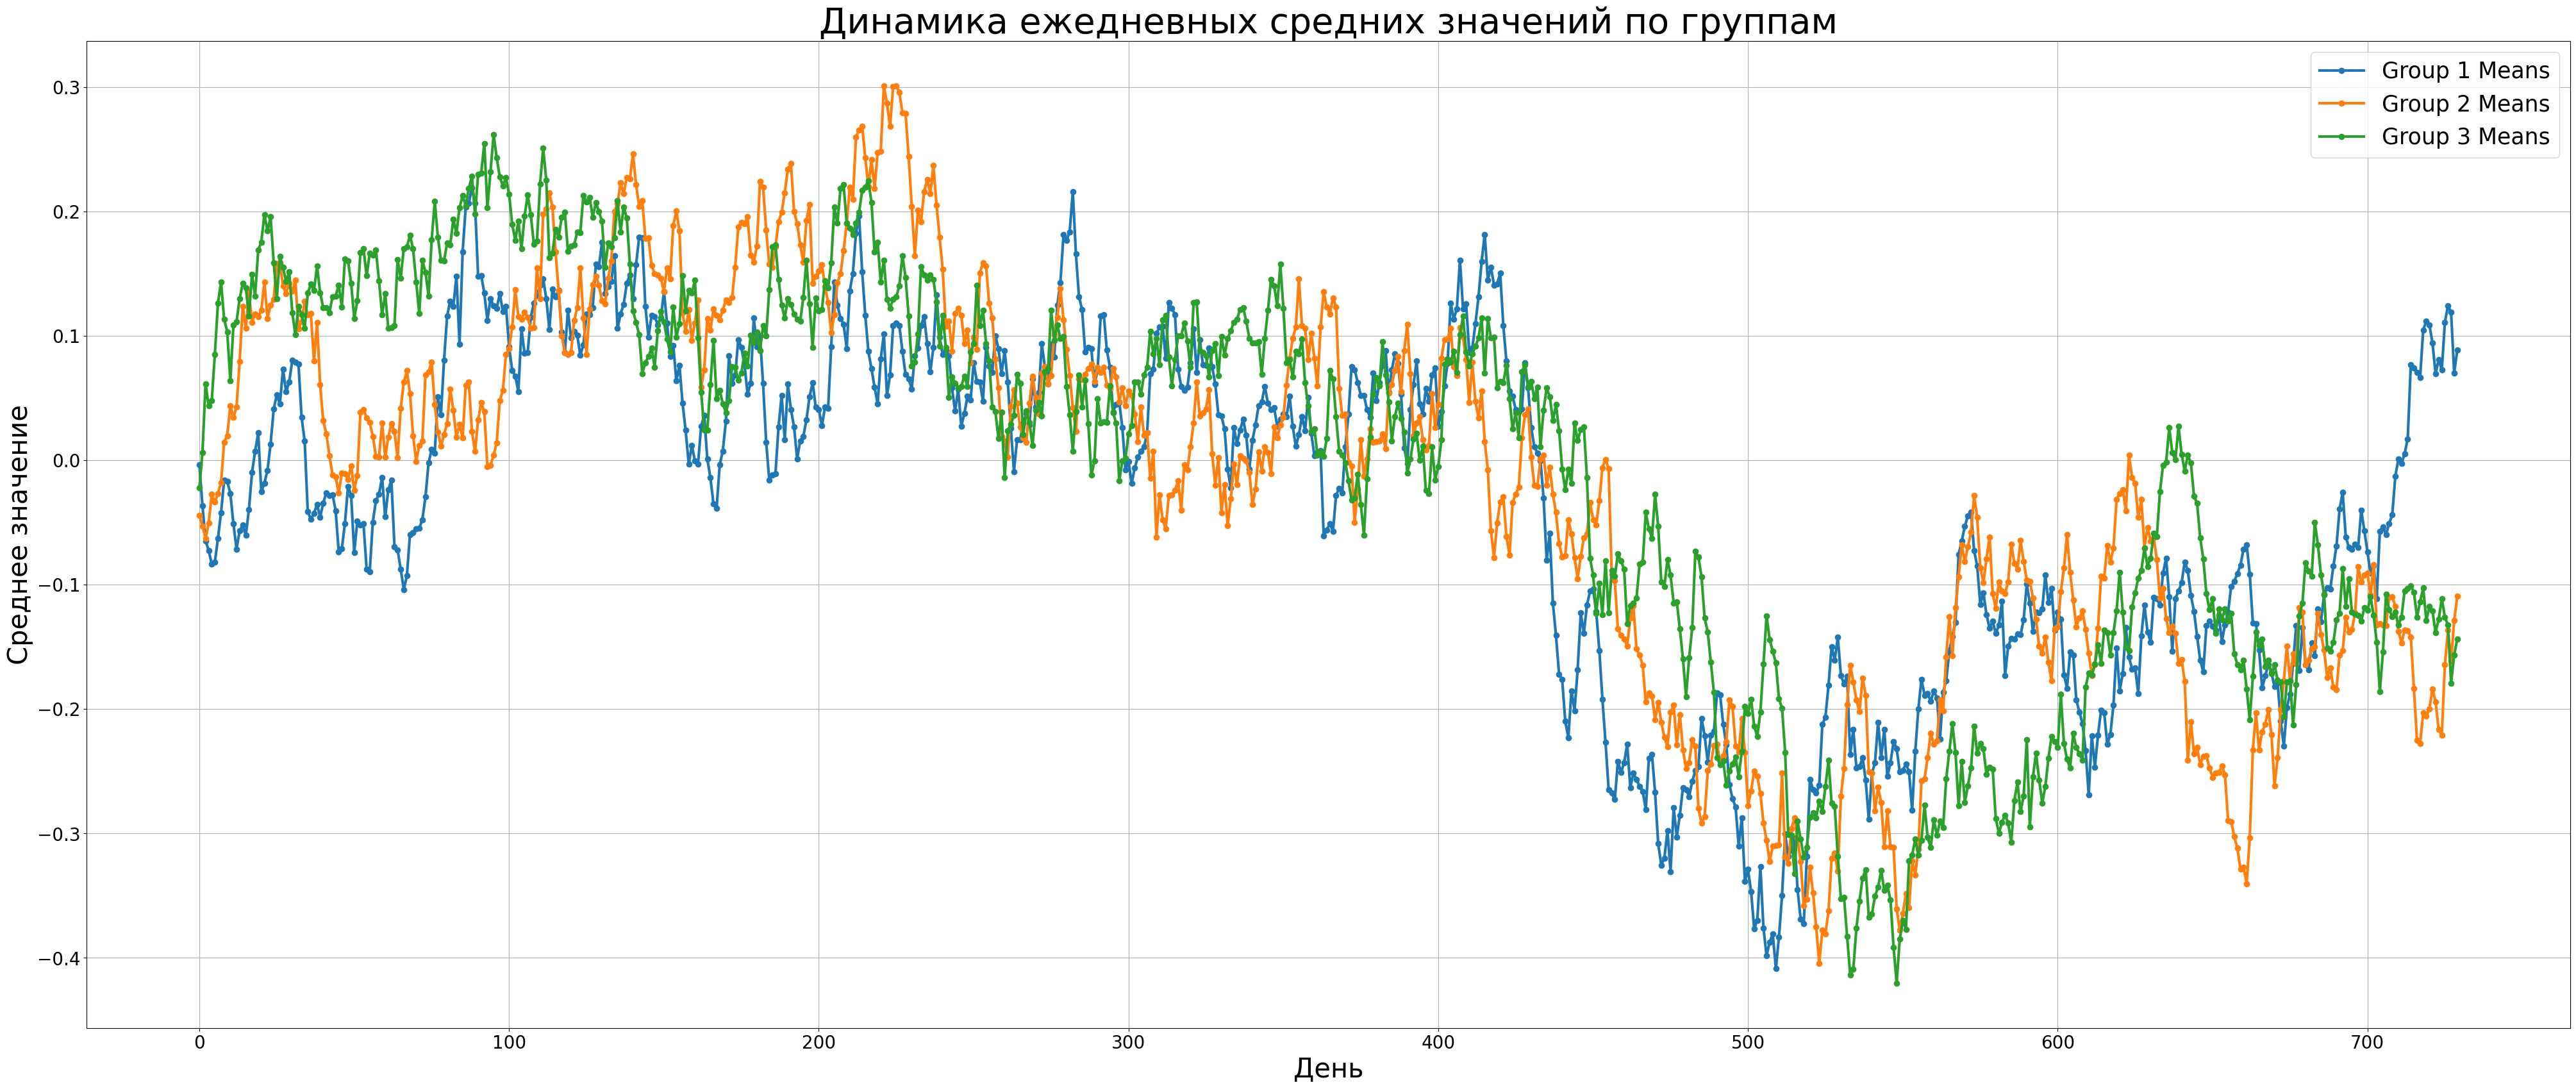

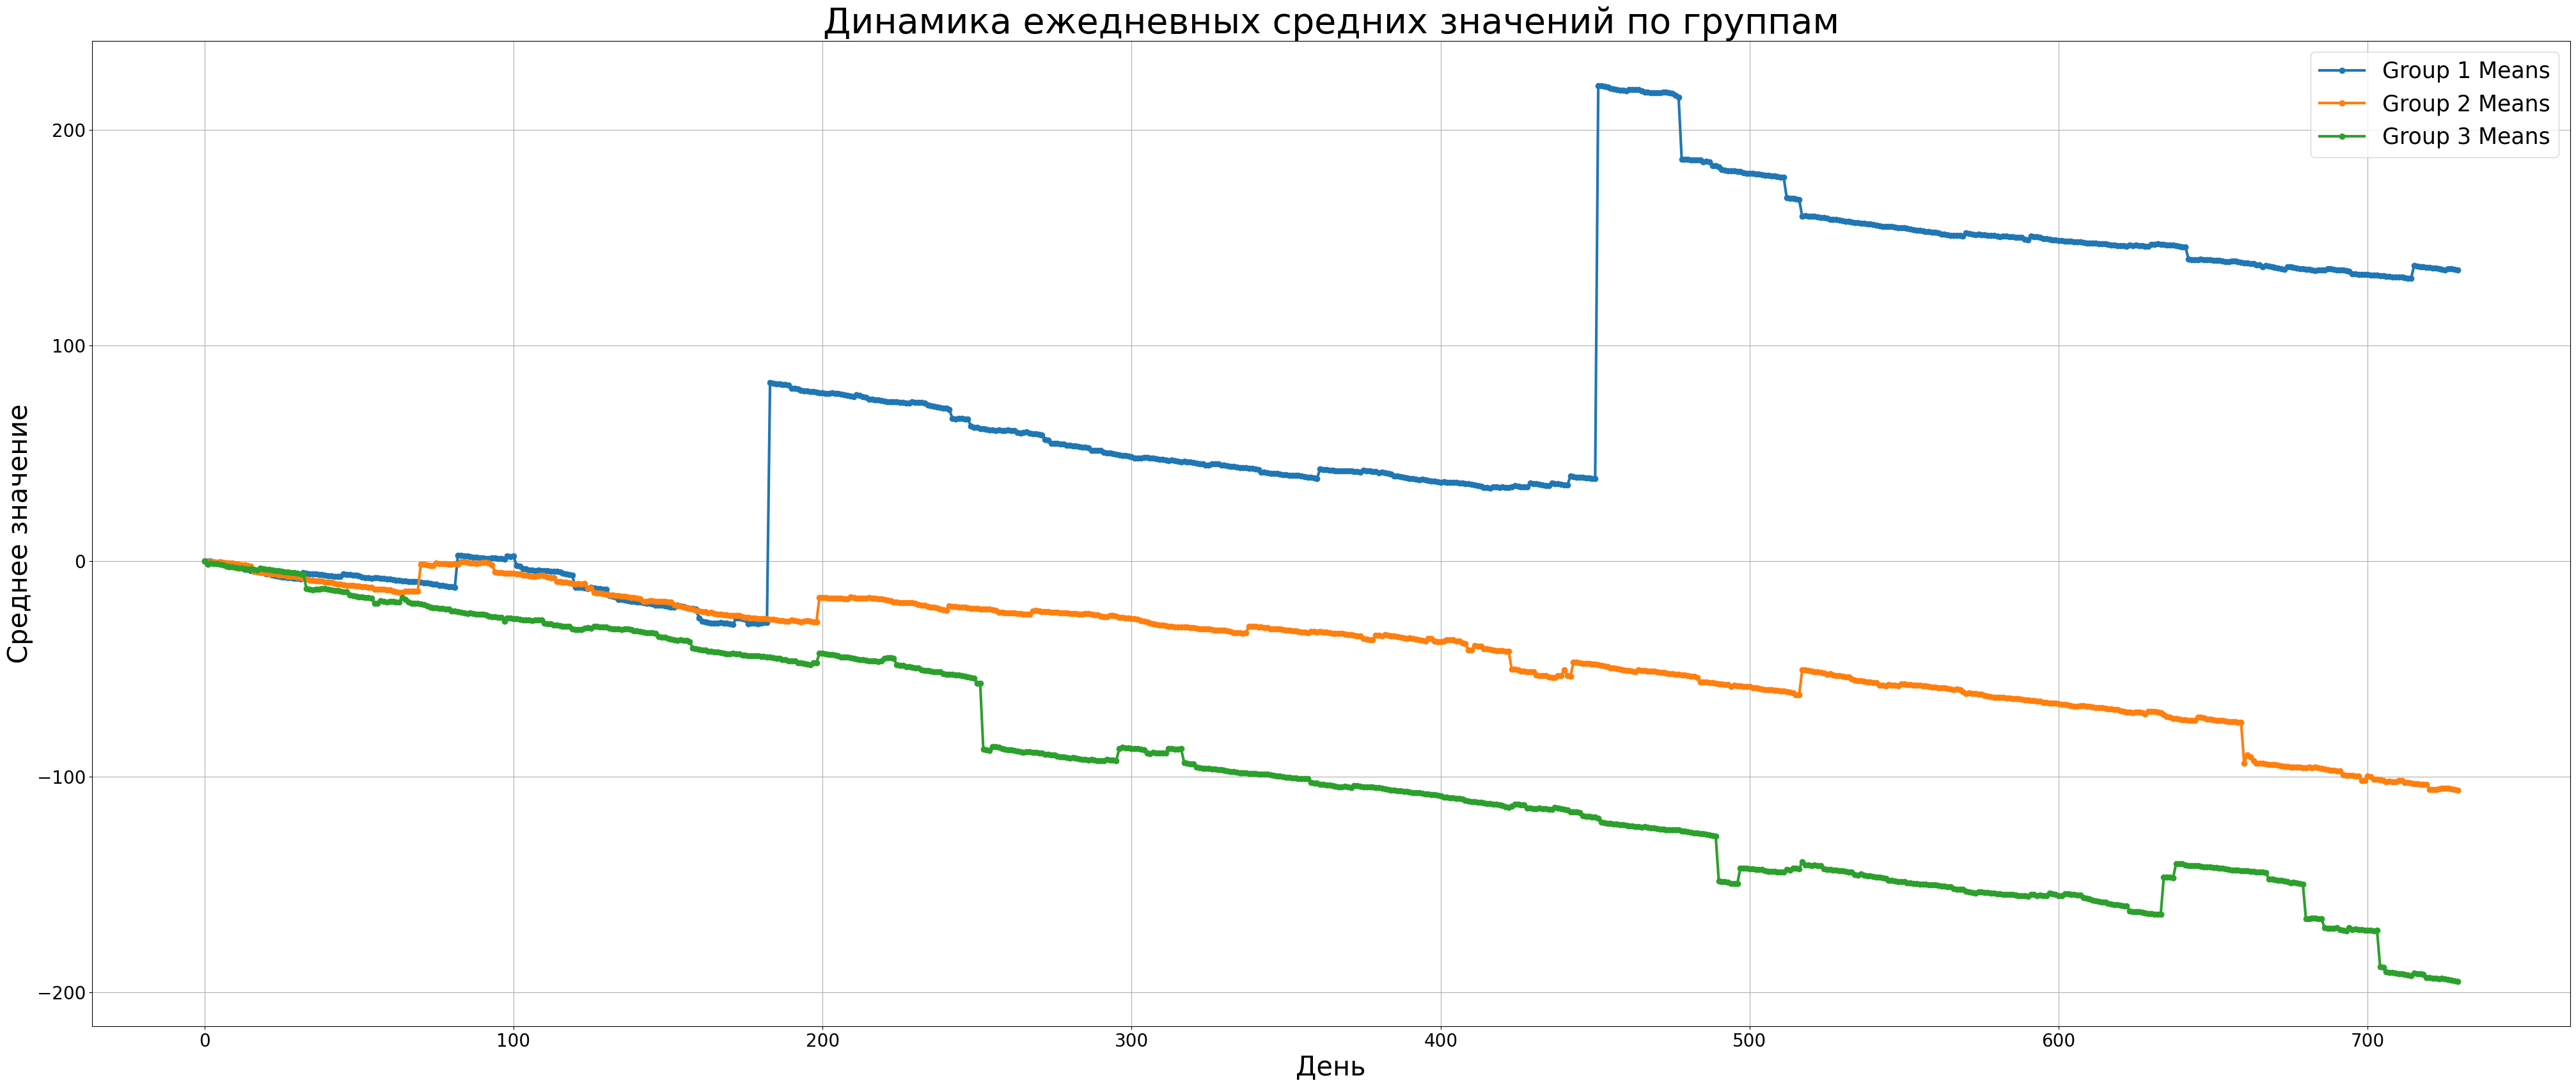

In [35]:
plot_daily_trend_means(groups)
plot_daily_trend_means(random_groups)

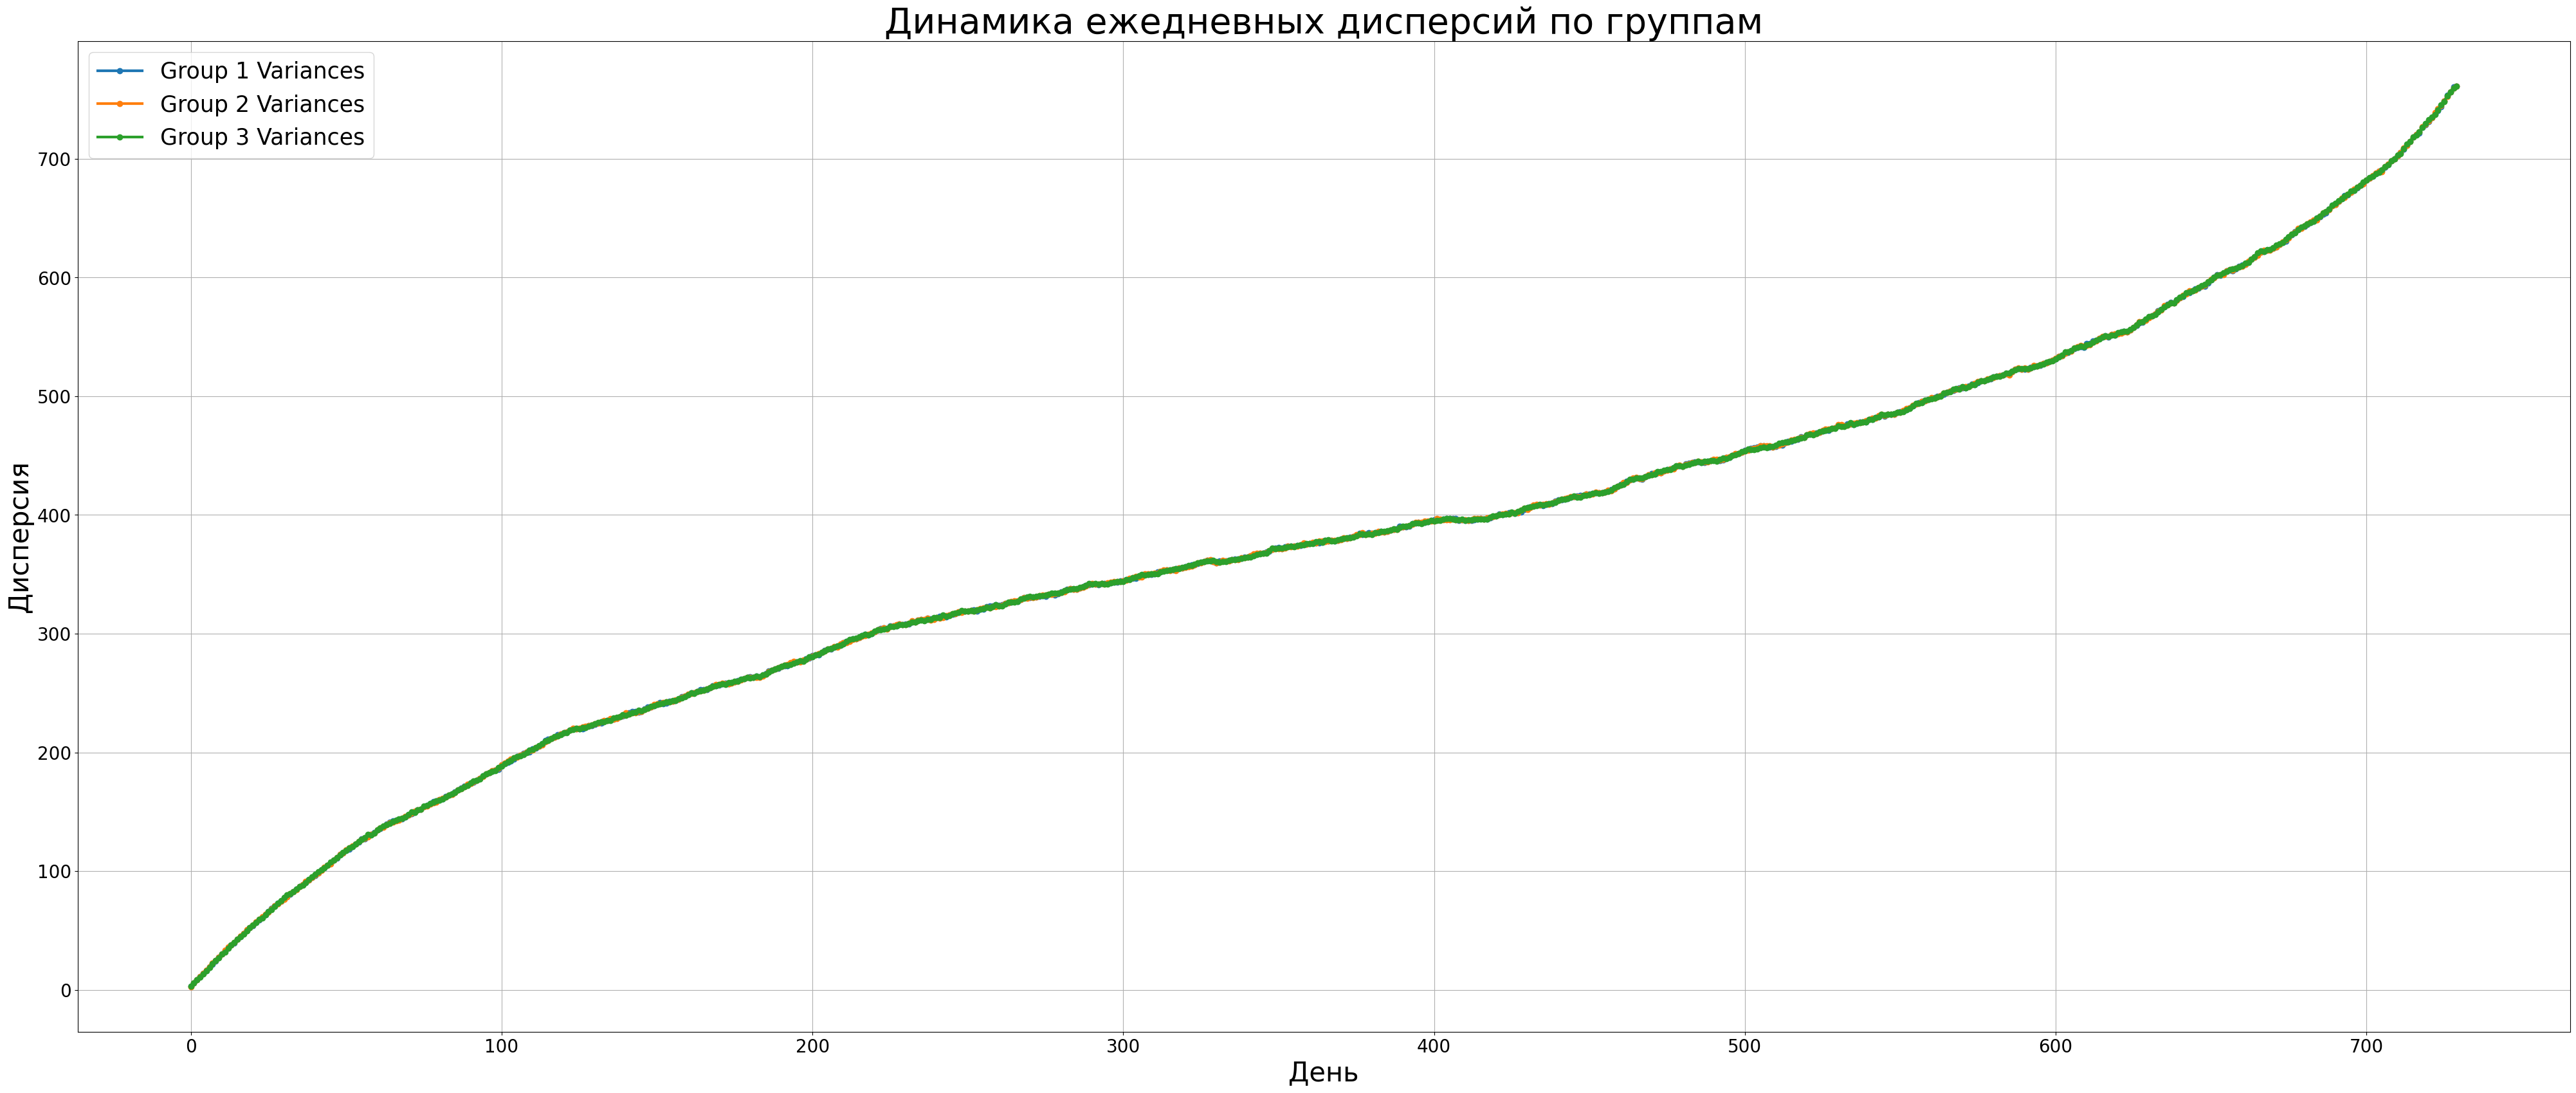

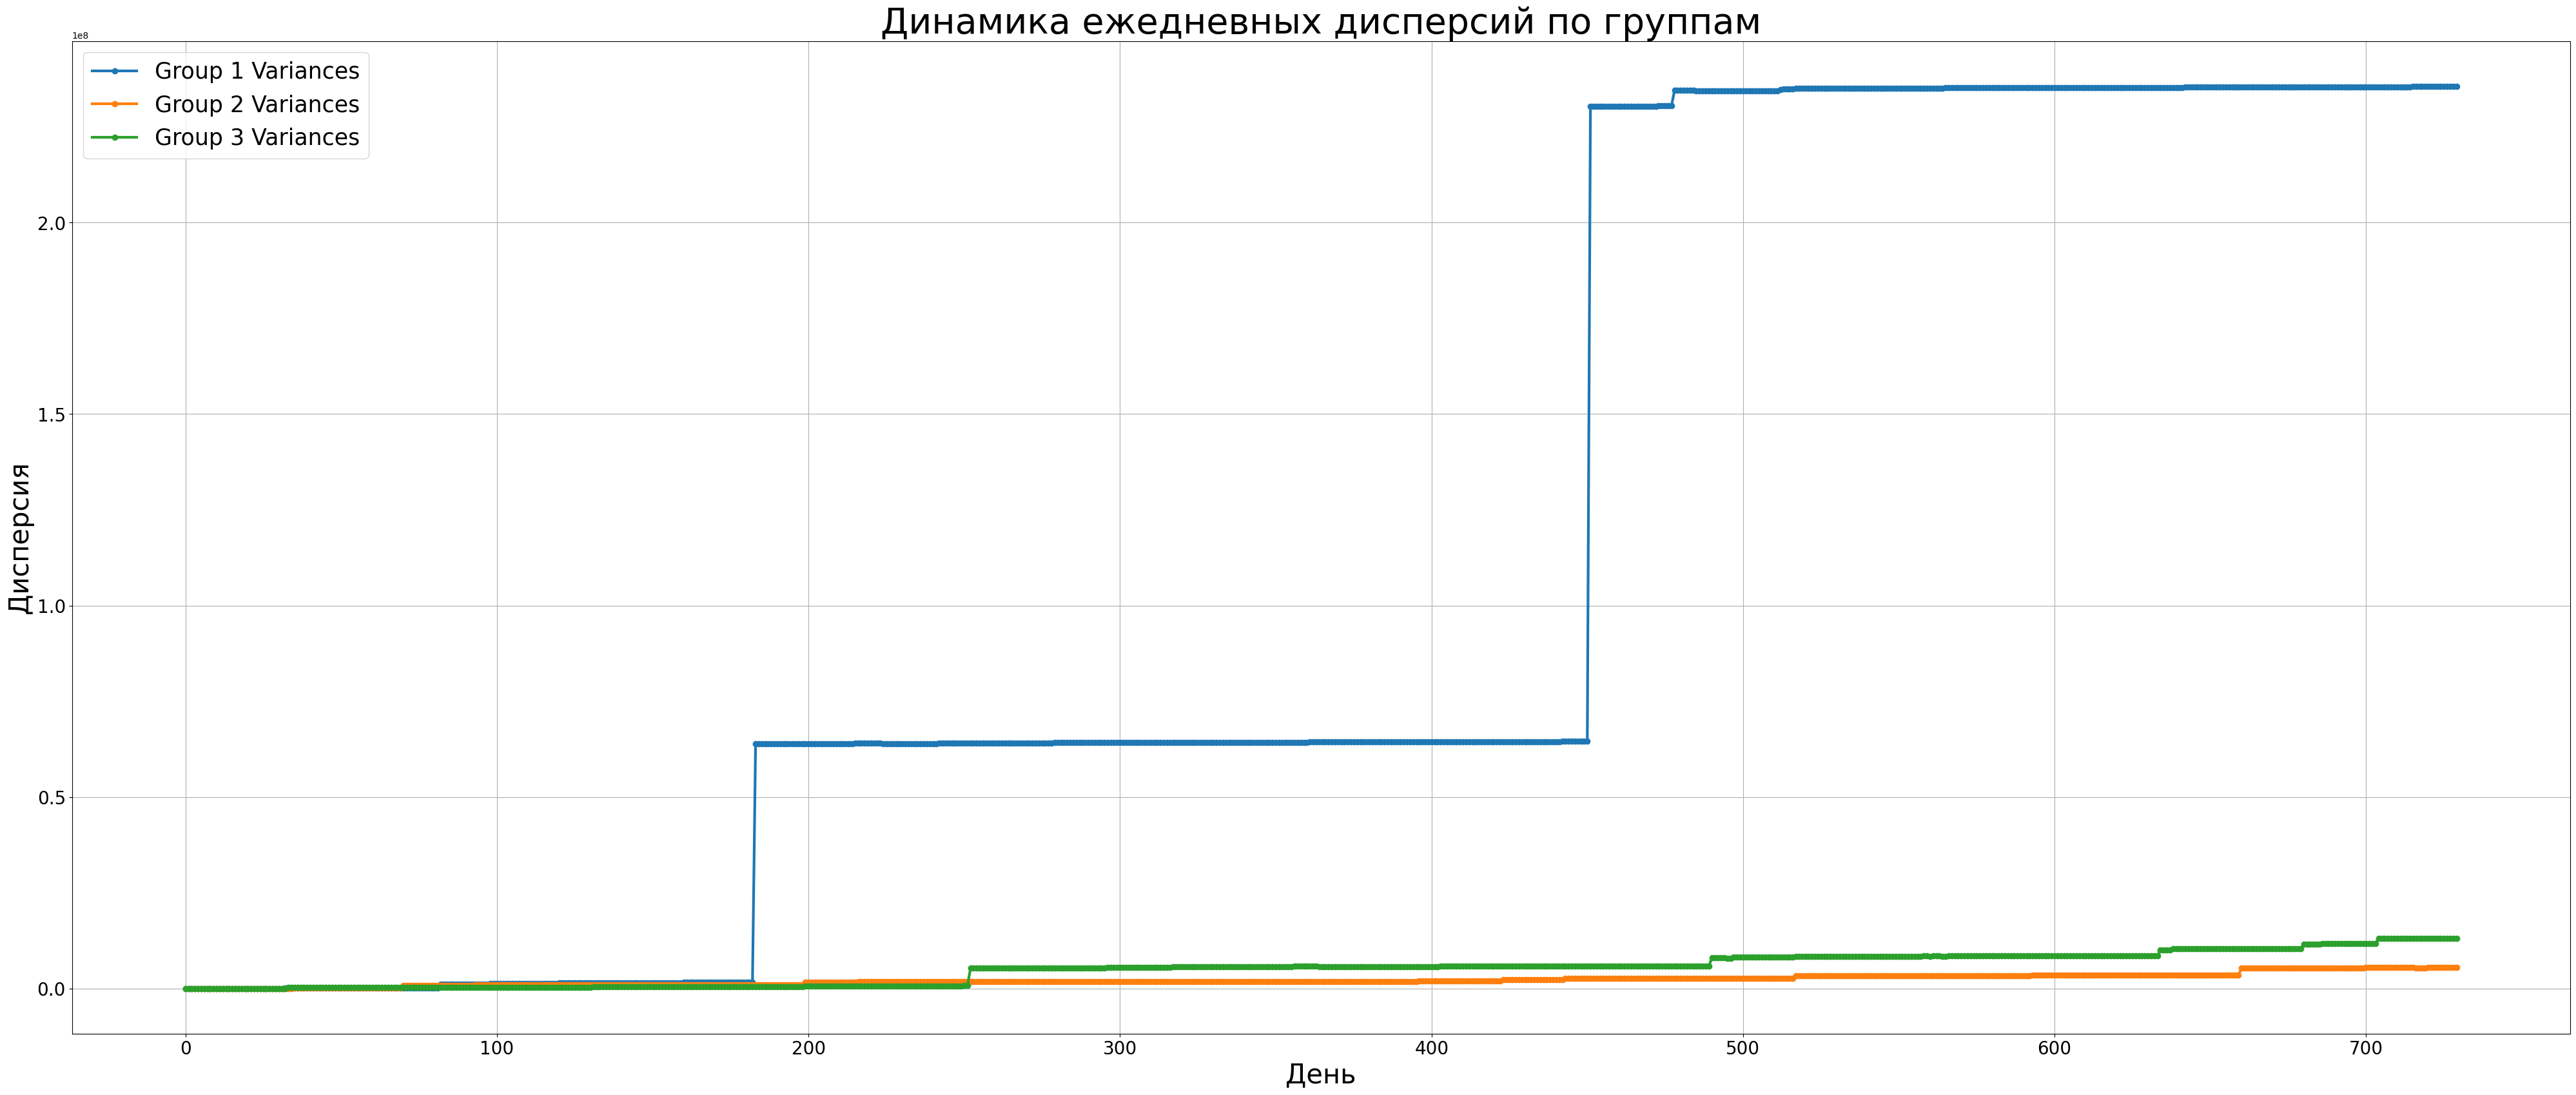

In [36]:
plot_daily_trend_variances(groups)
plot_daily_trend_variances(random_groups)